In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer
from scipy.spatial import Delaunay,delaunay_plot_2d
from collections import defaultdict
import mapbox_earcut as earcut
from shapely.geometry import Polygon, Point, LineString
epsillon = 10 ** -10

In [2]:
polygon_example_1 = [(5,5), (3,4), (6,3), (4,2), (6,0), (7,1), (8,4)]
polygon_example_2 = [(2,0), (5,1), (6,0), (8,3), (7,2), (8,7), (6,9), (5,8), (2,9), (1,7), (2,4), (4,5), (3,6), (5, 7), (5.5, 3), (2,2), (1,3), (0,1)]
polygon_example_3 = [(3125, 3215), (4853, 1052), (6968, 1694), (8413, 3405), (6280, 4379), (8079, 6780), (5540, 8111), (2596, 6162)]

# Ręczne zadawanie punktów

Funkcja add_polygon służy do ręcznego zadawania wierzchołków. Należy zadawać kolejne punkty wielokąta w kolejności ruchu wskazówek zegara. Nie można zadawać ich w dowolnej kolejności. (Oczywiście boki wielokąta nei mogą się przecinać)

-Punkty zadajemy pojedynczym kliknięciem lewym przyciskiem myszy

-Aby zakończyć zadawanie wielokąta, koniecznie użyć klawisza ESC

In [3]:
def add_polygon(polygon_manual):
    %matplotlib tk
    
    def onclick(event):
        nonlocal polygon_manual
    
        if event.button==1:
            x=event.xdata
            y=event.ydata

            polygon_manual.append((x,y))
            plt.scatter(x,y,color="blue")
            plt.show()
    
    def close(event):
        if event.key=="escape":
            plt.close()
            %matplotlib inline

    
    fig,ax=plt.subplots()
    plt.tight_layout()
    fig.canvas.mpl_connect("button_press_event",onclick)
    fig.canvas.mpl_connect("key_press_event",close)
    ax.set_xlim([0,1000])
    ax.set_ylim([0,1000])

In [4]:
polygon_manual=[]
add_polygon(polygon_manual)

In [5]:
print(polygon_manual)

[(374.2042894917246, 687.4834961711116), (271.96161002840074, 357.1428571428571), (554.0103809617078, 95.72220755215207), (857.2128097150131, 221.67942962767356), (499.3634315933796, 426.0628465804066), (728.5280579766917, 347.63665170319507), (825.482322985016, 594.7979931344071), (606.894525511703, 908.5027726432531)]


# Triangulacja Delaunaya

In [6]:
def del_vis(del_triangulation, points):
    plt.triplot(
        [p[0] for p in points],
        [p[1] for p in points],
        del_triangulation.simplices,
        color='blue'
    )
    plt.scatter(
        [p[0] for p in points],
        [p[1] for p in points],
        color='red'
    )
    plt.show()
    plt.close()

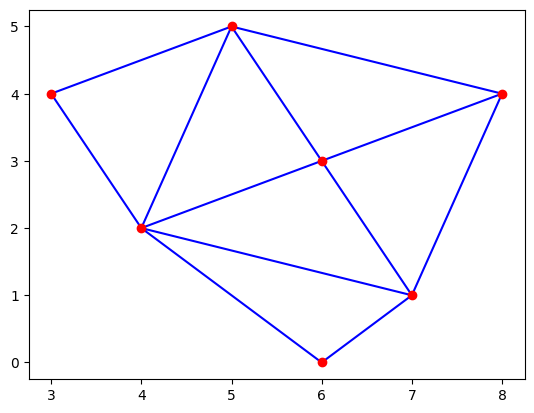

In [7]:
triangulation_delaunay_1 = Delaunay(polygon_example_1)
del_vis(triangulation_delaunay_1, polygon_example_1)

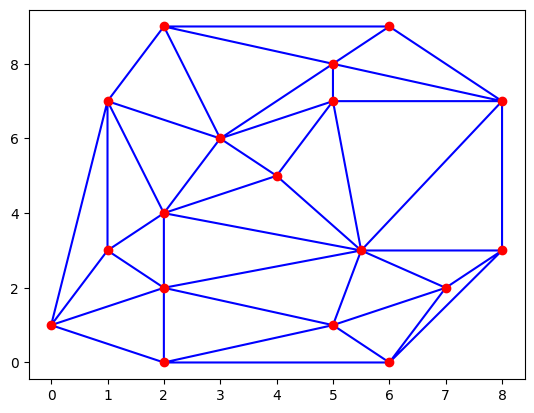

In [8]:
triangulation_delaunay_2 = Delaunay(polygon_example_2)
del_vis(triangulation_delaunay_2, polygon_example_2)

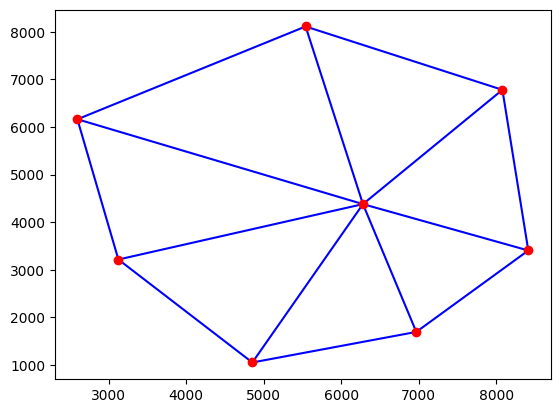

In [9]:
triangulation_delaunay_3 = Delaunay(polygon_example_3)
del_vis(triangulation_delaunay_3, polygon_example_3)

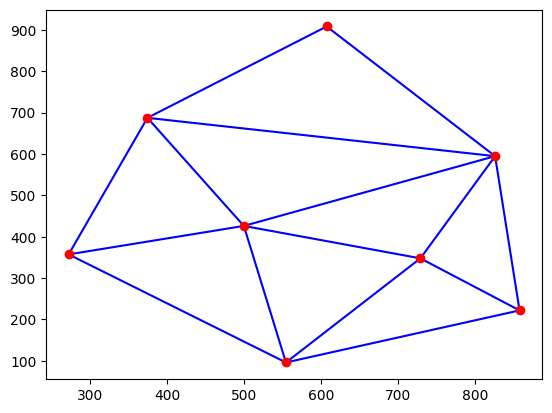

In [10]:
triangulation_delaunay_manual = Delaunay(polygon_manual)
del_vis(triangulation_delaunay_manual, polygon_manual)

# Traiangulacja earcut

In [11]:
def draw_earcut(verts, simplices):
    ax = plt.gca()  
    
    for a, b, c in simplices:
        triangle = [verts[a], verts[b], verts[c], verts[a]]  
        x, y = zip(*triangle) 
        ax.plot(x, y, color='red')  
    

    x, y = zip(*verts)
    ax.plot(list(x) + [x[0]], list(y) + [y[0]], color='blue', linewidth=2)  
    
    plt.show() 
    plt.close()

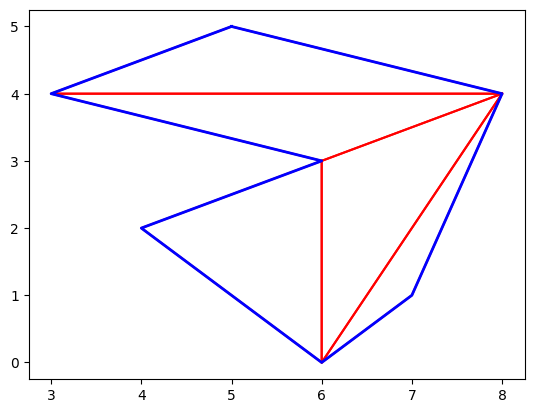

In [12]:
verts = np.array(polygon_example_1).reshape(-1, 2)
rings = np.array([len(polygon_example_1)])
result = earcut.triangulate_float64(verts, rings)
draw_earcut(verts, result.reshape(-1, 3))

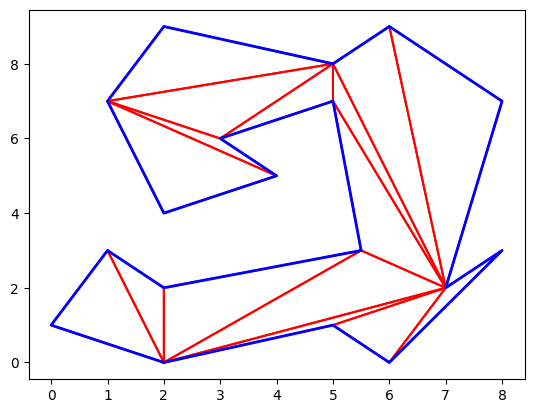

In [13]:
verts = np.array(polygon_example_2).reshape(-1, 2)
rings = np.array([len(polygon_example_2)])
result = earcut.triangulate_float64(verts, rings)
draw_earcut(verts, result.reshape(-1, 3))

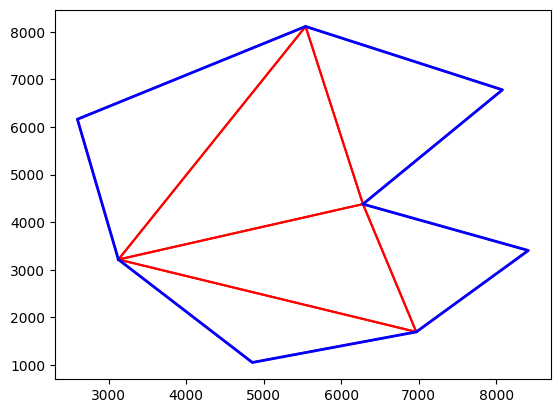

In [14]:
verts = np.array(polygon_example_3).reshape(-1, 2)
rings = np.array([len(polygon_example_3)])
result = earcut.triangulate_float64(verts, rings)
draw_earcut(verts, result.reshape(-1, 3))

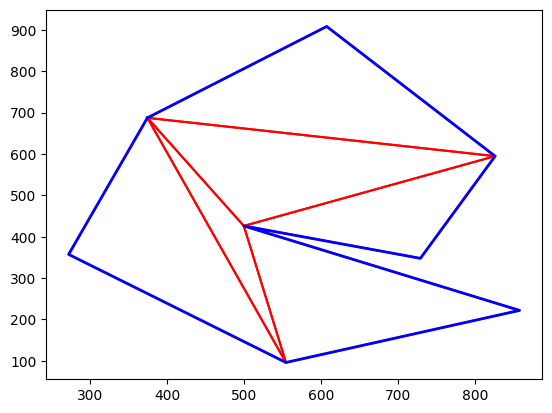

In [15]:
verts = np.array(polygon_manual).reshape(-1, 2)
rings = np.array([len(polygon_manual)])
result = earcut.triangulate_float64(verts, rings)
draw_earcut(verts, result.reshape(-1, 3))

# Outer space

In [16]:
def add_outer_space(points):
    max_height = float("-inf")
    min_height = float("inf")
    max_left = float("inf")
    max_right = float("-inf")
    for p in points:
        x, y = p
        if x < max_left:
            max_left = x
        if x > max_right:
            max_right = x
        if y < min_height:
            min_height = y
        if y > max_height:
            max_height = y

    width = max_right - max_left
    height = max_height - min_height
    margin = height * 0.5

    triangle = [
        (max_left - margin - width, min_height - margin),  # Lewy dół
        (max_right + margin + width, min_height - margin),  # Prawy dół
        ((max_left + max_right) / 2, max_height + height)  # Środek góra
    ]
    return triangle

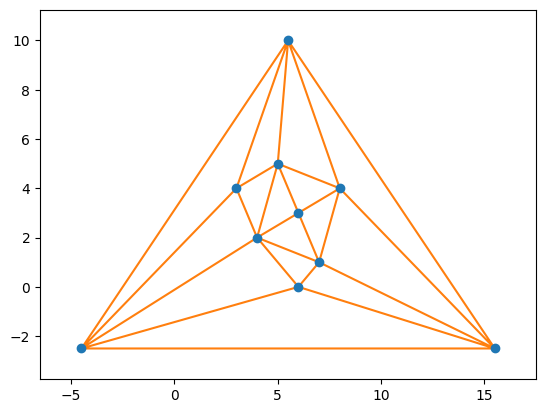

In [17]:
full_space_1 = polygon_example_1 + add_outer_space(polygon_example_1)
redundant1 = delaunay_plot_2d(Delaunay(full_space_1))

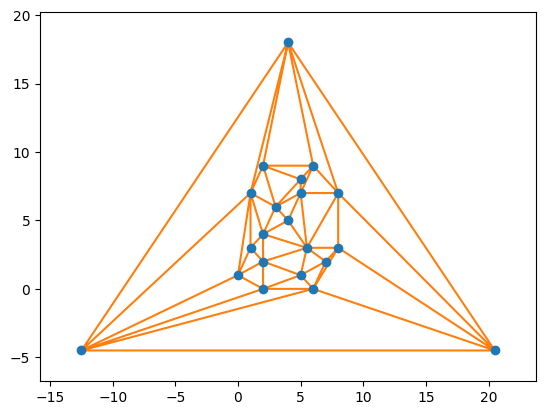

In [18]:
full_space_2 = polygon_example_2 + add_outer_space(polygon_example_2)
redundant2 = delaunay_plot_2d(Delaunay(full_space_2))

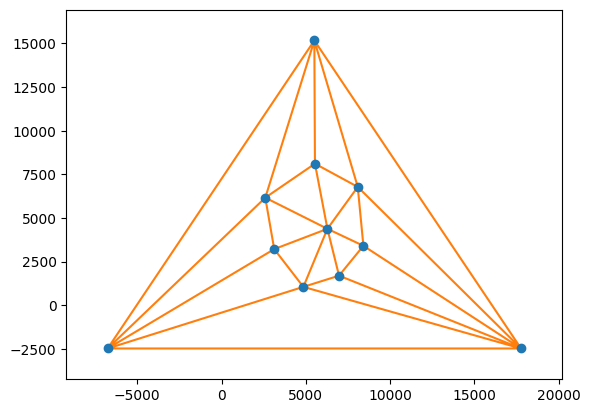

In [19]:
full_space_3 = polygon_example_3 + add_outer_space(polygon_example_3)
redundant3 = delaunay_plot_2d(Delaunay(full_space_3))

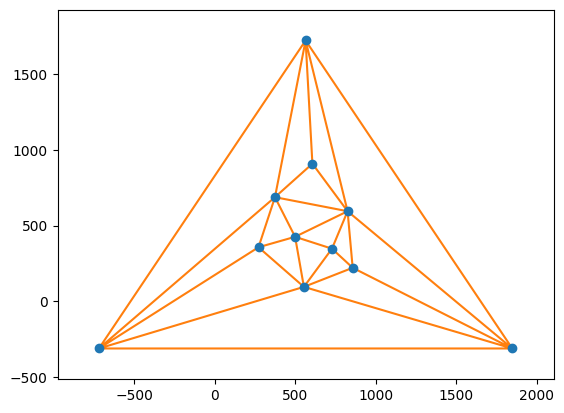

In [20]:
full_space_manual = polygon_manual + add_outer_space(polygon_manual)
redundant_manual = delaunay_plot_2d(Delaunay(full_space_manual))

# Funkcje pomocnicze

In [31]:
def get_independent_set(polygon, triangles, outer_space):
    # Punkty, które są połączone z dowolnym punktem niezależnym
    visited = set()
    
    # Zbiór niezależny
    independent_set = set()

    # Tworzymy mapę sąsiedztwa punktów na podstawie trójkątów
    point_neighbors = defaultdict(set)
    for triangle in triangles:
        for i in range(3):
            a, b = triangle[i], triangle[(i + 1) % 3]
            point_neighbors[a].add(b)
            point_neighbors[b].add(a)

    # Wybieramy punkty do niezależnego zbioru
    for point in polygon:
        if (
            point not in visited
            and point not in outer_space
            and len(point_neighbors[point]) <= 8  # Ograniczenie sąsiadów
        ):
            independent_set.add(point)
            # Oznaczamy sąsiadów jako odwiedzonych
            visited.update(point_neighbors[point])

    return list(independent_set)

In [22]:
def remove_independent_set(polygon, triangles, independent_set, outer_space):
    # Zbiór dziur i usuniętych trójkątów
    holes = []
    removed_triangles = []

    # Tworzenie mapy sąsiedztwa na podstawie trójkątów
    point_neighbors = {}
    for triangle in triangles:
        for i in range(3):
            a, b = triangle[i], triangle[(i + 1) % 3]
            point_neighbors.setdefault(a, set()).add(b)
            point_neighbors.setdefault(b, set()).add(a)

    # Dla każdego punktu w zbiorze niezależnym
    for independent_point in independent_set:
        if independent_point not in outer_space:
            # Usuwanie punktu z wielokąta
            if independent_point in polygon:
                polygon.remove(independent_point)

            # Zbieranie sąsiadów
            neighbors = list(point_neighbors.get(independent_point, []))
            if not neighbors:
                continue  # Brak sąsiadów, pomijamy

            # Tworzenie dziury
            hole = []
            visited = set()
            current = neighbors.pop(0)
            hole.append(current)

            while neighbors:
                visited.add(current)
                next_neighbor = None
                for neighbor in neighbors:
                    if neighbor in point_neighbors[current] and neighbor not in visited:
                        next_neighbor = neighbor
                        break
                if next_neighbor is not None:
                    hole.append(next_neighbor)
                    neighbors.remove(next_neighbor)
                    current = next_neighbor
                else:
                    break

            # Dodaj ostatniego sąsiada, jeśli jest
            if neighbors:
                hole.append(neighbors.pop(0))

            holes.append(hole)

            # Zbieranie trójkątów zawierających independent_point
            for tri in triangles:
                if independent_point in tri:
                    removed_triangles.append(tri)

    return holes, removed_triangles, polygon

In [23]:
def triangle_intersection(tri1, tri2):
    polygon1 = Polygon(tri1)
    polygon2 = Polygon(tri2)

    if polygon1.intersects(polygon2):
        # Znajdź przecięcie
        intersection = polygon1.intersection(polygon2)

        # Jeśli przecięcie to wielokąt z powierzchnią, uznajemy za przecięcie
        if intersection.geom_type == "Polygon" and not intersection.is_empty:
            return True

        # Jeśli przecięcie to linia, sprawdzenie czy jest krawędzią
        if intersection.geom_type == "LineString" and not intersection.is_empty:
            edges1 = [
                LineString([polygon1.exterior.coords[i], polygon1.exterior.coords[i + 1]])
                for i in range(3)
            ]
            edges2 = [
                LineString([polygon2.exterior.coords[i], polygon2.exterior.coords[i + 1]])
                for i in range(3)
            ]

            # Jeśli przecięcie to krawędź, ignorujemy
            for edge in edges1 + edges2:
                if intersection.equals(edge):
                    return False

        # Jeśli przecięcie to punkt, ignorujemy
        if intersection.geom_type == "Point" and not intersection.is_empty:
            return False

    return False

# Kirkpatrick

In [24]:
def kirkpatrick(polygon):
    #polygon [(x,y),(x,y),(x,y)....]
    # Dodajemy zewnętrzny trójkąt
    outer_space = add_outer_space(polygon)
    full_polygon = polygon + outer_space

    # Tworzymy triangulację Delaunaya
    delaunay_triangulation = Delaunay(full_polygon)
    outer_space = tuple(outer_space)
    
    # Triangulacja jako graf
    triangles_graph = {}
    

    # Mapowanie trójkątów
    for a, b, c in delaunay_triangulation.simplices:
        triangle = ((full_polygon[a], full_polygon[b], full_polygon[c]))
        triangles_graph[triangle] = []

    v = len(full_polygon)
    
    while v > 3: # jeżeli zostaną tylko 3 to będzie to zewnętrzny trójkąt
        #print(v)
        
        # Wyciągamy niezależny zbiór punktów
        independent_set = get_independent_set(full_polygon, [key for key, value in triangles_graph.items() if "removed" not in value], outer_space)
        
        # zmniejszamy ilość punktów w grafie
        v -= len(independent_set)

        # znajdujemy dziury i usunięte trójkąty
        holes, all_removed_triangles, full_polygon = remove_independent_set(full_polygon,[key for key, value in triangles_graph.items() if "removed" not in value], independent_set, outer_space)
        
        
        # Ozanczenie usuniętych trójkątów
        for tri in triangles_graph:
            if tri in all_removed_triangles:
                triangles_graph[tri].append("removed")
                
        #retriangulacja dziur
        for hole_points in holes:
            verts = np.array([[point[0], point[1]] for point in hole_points]).reshape(-1, 2)
            rings = np.array([len(hole_points)])
            result = earcut.triangulate_float64(verts, rings)
            for a, b, c in result.reshape(-1, 3):
                new_triangle = ((hole_points[a], hole_points[b], hole_points[c]))
                last_triangle = new_triangle

                
                TMP = []
                    
                # Tworzenie Hierarhi nachodzenia trójkątów
                for old_triangle in triangles_graph:
                    if old_triangle in all_removed_triangles:
                        if triangle_intersection(new_triangle, old_triangle):
                            TMP.append(old_triangle)
                triangles_graph[new_triangle] = TMP
    return triangles_graph, last_triangle, delaunay_triangulation

# Lokalizacja Punktu w hierarchi

In [25]:
def locate(triangles_graph, outer_space, point):
    
    point_geom = Point(point)

    # Czy punkt znajduje się w zewnętrznym trójkącie
    root_polygon = Polygon(outer_space)
    if not root_polygon.contains(point_geom):
        return None

    current = tuple(outer_space)

    while triangles_graph.get(current):
        # Sprawdzenie, czy dotarliśmy do trójkąta początkowej triangulacji
        if triangles_graph[current] == ['removed']:
            break

        # Iteracja po trójkątach sąsiadujących
        found = False
        for triangle in triangles_graph[current]:
            if triangle == "removed":
                continue

            triangle_polygon = Polygon(triangle)

            # Czy punkt znajduje się w trójkącie
            if triangle_polygon.contains(point_geom):
                current = tuple(triangle)
                found = True
                break

            # Czy punkt leży na krawędzi z tolerancją epsillon
            for i in range(3):
                edge = LineString([triangle[i], triangle[(i + 1) % 3]])
                if point_geom.distance(edge) <= epsillon:
                    current = tuple(triangle)
                    found = True
                    break

            if found:
                break

        if not found:
            break

    return current

# Vizualizacja

In [26]:
def kirkpatrick_vis(polygon):
    vis=Visualizer()

    #polygon [(x,y),(x,y),(x,y)....]
    # Dodajemy zewnętrzny trójkąt

    outer_space = add_outer_space(polygon)
    full_polygon = polygon + outer_space

    vis.add_point(polygon,color="green")
    vis.add_point(outer_space,color="green")

    # Tworzymy triangulację Delaunaya
    delaunay_triangulation = Delaunay(full_polygon)
    outer_space = tuple(outer_space)
    
    # Triangulacja jako graf
    triangles_graph = {}
    triangles_graph_vis = {}

    all_triangulations=[]
    one_triangulation=set()
    
    for a, b, c in delaunay_triangulation.simplices:

        triangle_vis = vis.add_line_segment([(full_polygon[a], full_polygon[b]), (full_polygon[b],full_polygon[c]), (full_polygon[c],full_polygon[a])], alpha=0.7)

        triangle = (full_polygon[a], full_polygon[b], full_polygon[c])
        
        one_triangulation.add((full_polygon[a], full_polygon[b]))
        one_triangulation.add((full_polygon[b], full_polygon[c]))
        one_triangulation.add((full_polygon[c], full_polygon[a]))

        triangles_graph[triangle] = []
        triangles_graph_vis[triangle]=[triangle_vis]#,triangle_p_vis]
    
    all_triangulations.append(one_triangulation.copy())
    vis.show()
    
    v = len(full_polygon)

    
    
    while v > 3: # jeżeli zostaną tylko 3 to będzie to zewnętrzny trójkąt
        
        # Wyciągamy niezależny zbiór punktów
        independent_set = get_independent_set(full_polygon, [key for key, value in triangles_graph.items() if "removed" not in value], outer_space)
        
        independent_set_vis_save=[]
        for px, py in independent_set:
            independent_set_vis=vis.add_point((px,py), color="red")
            independent_set_vis_save.append(independent_set_vis)
        
        # zmniejszamy ilość punktów w grafie
        v -= len(independent_set)

        # znajdujemy dziury i usunięte trójkąty
        holes, all_removed_triangles, full_polygon = remove_independent_set(full_polygon,[key for key, value in triangles_graph.items() if "removed" not in value], independent_set, outer_space)
        for a,b,c in all_removed_triangles:
            if (a,b) in one_triangulation:
                one_triangulation.remove((a,b))
            if (b,c) in one_triangulation:
                one_triangulation.remove((b,c))
            if (c,a) in one_triangulation:
                one_triangulation.remove((c,a))
    
        
        # Ozanczenie usuniętych trójkątów
        for tri in triangles_graph:
            if tri in all_removed_triangles:
                triangles_graph[tri].append("removed")

                vis.remove_figure(triangles_graph_vis[tri][0])

        for px, py in independent_set:
            independent_set_vis=vis.add_point((px,py), color="lightgreen")
                
        #retriangulacja dziur
        for hole_points in holes:
            verts = np.array([[point[0], point[1]] for point in hole_points]).reshape(-1, 2)
            rings = np.array([len(hole_points)])
            result = earcut.triangulate_float64(verts, rings)
            for a, b, c in result.reshape(-1, 3):
                new_triangle = ((hole_points[a], hole_points[b], hole_points[c]))
                last_triangle = new_triangle

                
                TMP = []
                    
                # Tworzenie Hierarhi nachodzenia trójkątów
                for old_triangle in triangles_graph:
                    if old_triangle in all_removed_triangles:
                        if triangle_intersection(new_triangle, old_triangle):
                            TMP.append(old_triangle)
                triangles_graph[new_triangle] = TMP

                triangle_vis = vis.add_line_segment([(hole_points[a], hole_points[b]), (hole_points[b], hole_points[c]), (hole_points[c], hole_points[a])], alpha=0.7)
                
                one_triangulation.add((hole_points[a], hole_points[b]))
                one_triangulation.add((hole_points[b], hole_points[c]))
                one_triangulation.add((hole_points[c], hole_points[a]))

                triangles_graph_vis[new_triangle]=[triangle_vis]#,triangle_p_vis]
        all_triangulations.append(one_triangulation.copy())
        vis.show()
    
    vis.save_gif('plot',interval=500)
    return triangles_graph, last_triangle, delaunay_triangulation, all_triangulations

In [27]:
def locate_vis(triangles_graph, outer_space, point, all_triangulations):
    vis=Visualizer()

    vis.add_point(point, color="red")

    current_segments=[]
    while len(all_triangulations[len(all_triangulations)-1]):
        cs=all_triangulations[len(all_triangulations)-1].pop()
        current_segments.append(cs)
    vis_del=vis.add_line_segment(current_segments)
    vis_del_poly=vis.add_polygon([current_segments[0][0],current_segments[1][0],current_segments[2][0]],alpha=0.5)
    vis.remove_figure(vis_del_poly)
    vis.remove_figure(vis_del)
    
    iterator=1

    point_geom = Point(point)

    # Czy punkt znajduje się w zewnętrznym trójkącie
    root_polygon = Polygon(outer_space)
    if not root_polygon.contains(point_geom):
        return None

    current = tuple(outer_space)

    current_save=current

    while triangles_graph.get(current):

        if current_save!=current:
            current_save=current
            current_segments=[]

            while len(all_triangulations)-1-iterator>=0 and not ((current[0],current[1]) in all_triangulations[len(all_triangulations)-1-iterator] and (current[1],current[2]) in all_triangulations[len(all_triangulations)-1-iterator] and (current[2],current[0]) in all_triangulations[len(all_triangulations)-1-iterator]):
            #while not (((current[0],current[1]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[1],current[0]) in all_triangulations[len(all_triangulations)-1-iterator]) and ((current[1],current[2]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[2],current[1]) in all_triangulations[len(all_triangulations)-1-iterator]) and ((current[2],current[0]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[0],current[2]) in all_triangulations[len(all_triangulations)-1-iterator])):
                iterator+=1
            while len(all_triangulations[len(all_triangulations)-1-iterator]):
                cs=all_triangulations[len(all_triangulations)-1-iterator].pop()
                current_segments.append(cs)
            vis_del=vis.add_line_segment(current_segments)
            vis_del_poly=vis.add_polygon(current,alpha=0.5)
            vis.show()
            vis.remove_figure(vis_del_poly)
            vis.remove_figure(vis_del)
    
            iterator+=1

        # Sprawdzenie, czy dotarliśmy do trójkąta początkowej triangulacji
        if triangles_graph[current] == ['removed']:
            break

        # Iteracja po trójkątach sąsiadujących
        found = False
        for triangle in triangles_graph[current]:
            if triangle == "removed":
                continue

            triangle_polygon = Polygon(triangle)

            # Czy punkt znajduje się w trójkącie
            if triangle_polygon.contains(point_geom):
                current = tuple(triangle)
                found = True
                break

            # Czy punkt leży na krawędzi z tolerancją epsillon
            for i in range(3):
                edge = LineString([triangle[i], triangle[(i + 1) % 3]])
                if point_geom.distance(edge) <= epsillon:
                    current = tuple(triangle)
                    found = True
                    break

            if found:
                break

        if not found:
            break
    vis.save_gif('plot2',interval=500)
    return current

In [28]:
def locate_vis2(triangles_graph, outer_space, point, all_triangulations):
    vis=Visualizer()

    vis.add_point(point, color="red")

    current_segments=[]
    while len(all_triangulations[len(all_triangulations)-1]):
        cs=all_triangulations[len(all_triangulations)-1].pop()
        current_segments.append(cs)
    vis_del=vis.add_line_segment(current_segments)
    vis_del_poly=vis.add_polygon([current_segments[0][0],current_segments[1][0],current_segments[2][0]],alpha=0.3)
    vis.add_point(point, color="red")
    vis.remove_figure(vis_del)
    
    iterator=1

    point_geom = Point(point)

    # Czy punkt znajduje się w zewnętrznym trójkącie
    root_polygon = Polygon(outer_space)
    if not root_polygon.contains(point_geom):
        return None

    current = tuple(outer_space)

    current_save=current

    while triangles_graph.get(current):

        if current_save!=current:
            current_save=current
            current_segments=[]

            while len(all_triangulations)-1-iterator>=0 and not ((current[0],current[1]) in all_triangulations[len(all_triangulations)-1-iterator] and (current[1],current[2]) in all_triangulations[len(all_triangulations)-1-iterator] and (current[2],current[0]) in all_triangulations[len(all_triangulations)-1-iterator]):
            #while not (((current[0],current[1]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[1],current[0]) in all_triangulations[len(all_triangulations)-1-iterator]) and ((current[1],current[2]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[2],current[1]) in all_triangulations[len(all_triangulations)-1-iterator]) and ((current[2],current[0]) in all_triangulations[len(all_triangulations)-1-iterator] or (current[0],current[2]) in all_triangulations[len(all_triangulations)-1-iterator])):
                iterator+=1
            while len(all_triangulations[len(all_triangulations)-1-iterator]):
                cs=all_triangulations[len(all_triangulations)-1-iterator].pop()
                current_segments.append(cs)
            vis_del=vis.add_line_segment(current_segments)
            vis_del_poly=vis.add_polygon(current,alpha=0.3)
            vis.add_point(point, color="red")
            vis.remove_figure(vis_del)
            
    
            iterator+=1

        # Sprawdzenie, czy dotarliśmy do trójkąta początkowej triangulacji
        if triangles_graph[current] == ['removed']:
            break

        # Iteracja po trójkątach sąsiadujących
        found = False
        for triangle in triangles_graph[current]:
            if triangle == "removed":
                continue

            triangle_polygon = Polygon(triangle)

            # Czy punkt znajduje się w trójkącie
            if triangle_polygon.contains(point_geom):
                current = tuple(triangle)
                found = True
                break

            # Czy punkt leży na krawędzi z tolerancją epsillon
            for i in range(3):
                edge = LineString([triangle[i], triangle[(i + 1) % 3]])
                if point_geom.distance(edge) <= epsillon:
                    current = tuple(triangle)
                    found = True
                    break

            if found:
                break

        if not found:
            break
    vis_del=vis.add_line_segment([(current[0],current[1]),(current[1],current[2]),(current[2],current[0])],color="orange")
    vis.show()
    vis.save_gif('plot3',interval=500)
    return current

# Działanie

In [29]:
chosen_polygon=polygon_example_3

In [32]:
triangles_graph, root, delaunay_triangulation = kirkpatrick(chosen_polygon)

In [33]:
point_to_locate = (5,5)
found_triangle = locate(triangles_graph, root, point_to_locate)
print(found_triangle)

((4853, 1052), (3125, 3215), (-6750.5, -2477.5))


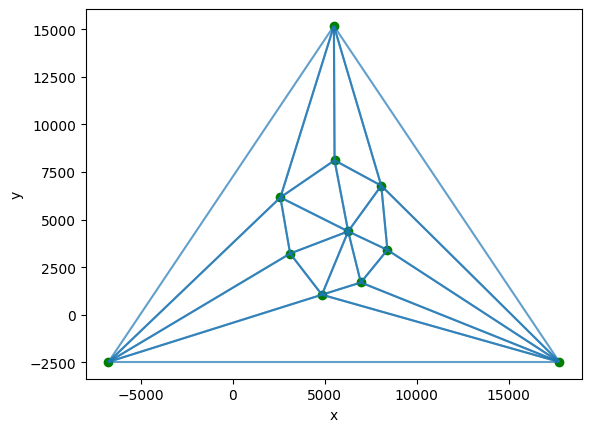

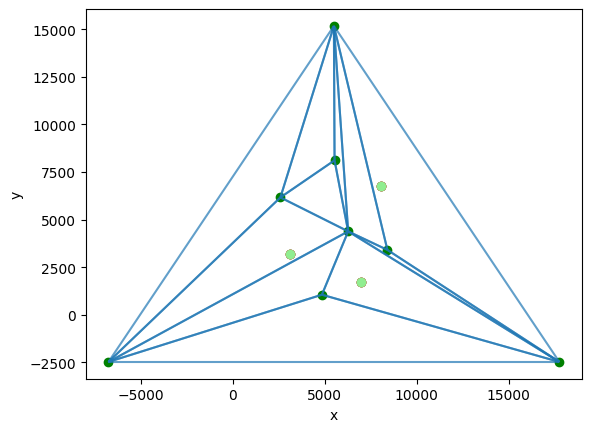

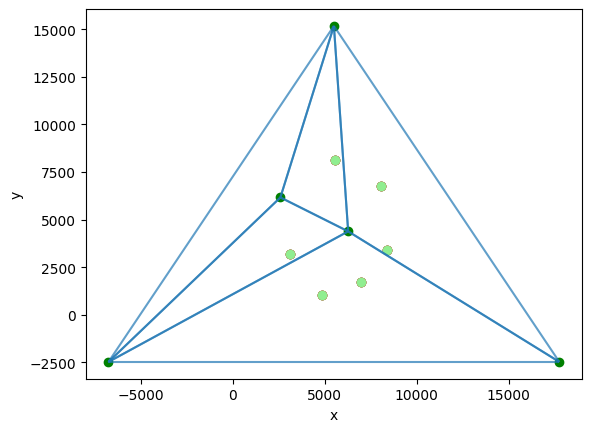

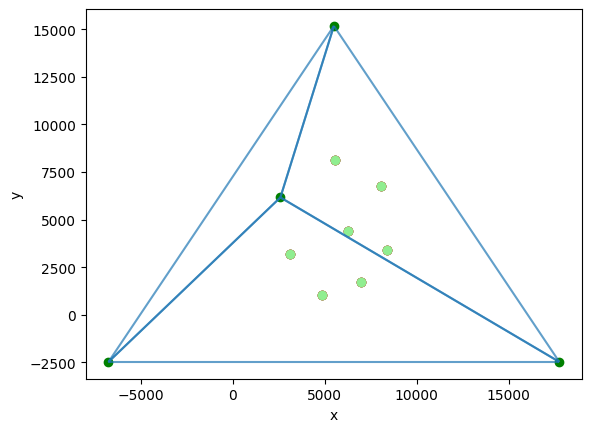

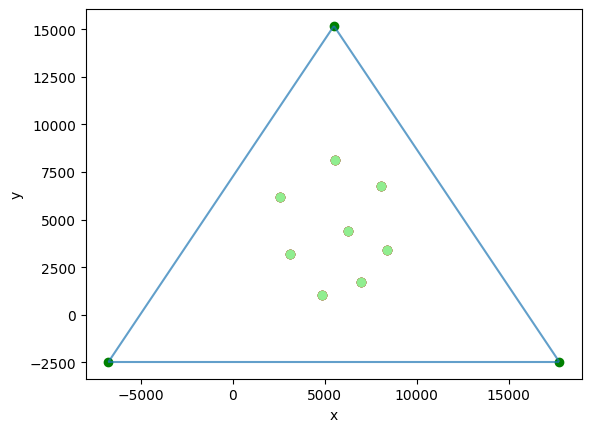

In [34]:
triangles_graph, root, delaunay_triangulation, all_triangulations = kirkpatrick_vis(chosen_polygon)

((5504.5, 15170), (-6750.5, -2477.5), (17759.5, -2477.5))
((4853, 1052), (3125, 3215), (-6750.5, -2477.5))


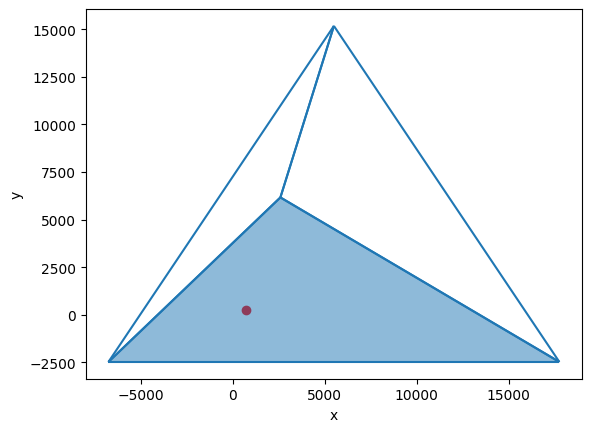

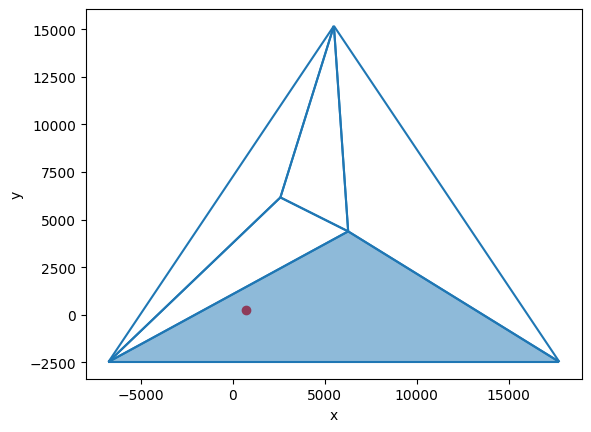

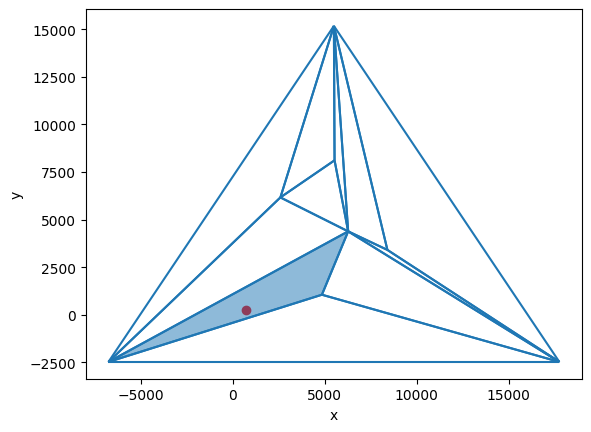

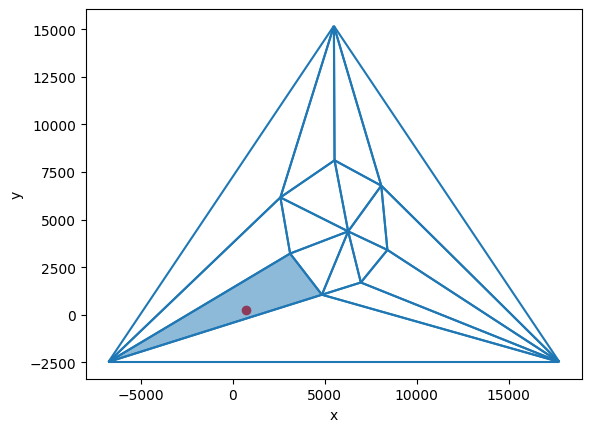

In [35]:
point_to_locate = (700,250)
print(root)
all_triangulations_copy=[all_triangulations[i].copy() for i in range(len(all_triangulations))]
found_triangle = locate_vis(triangles_graph, root, point_to_locate, all_triangulations_copy)
print(found_triangle)

((5504.5, 15170), (-6750.5, -2477.5), (17759.5, -2477.5))
((4853, 1052), (3125, 3215), (-6750.5, -2477.5))


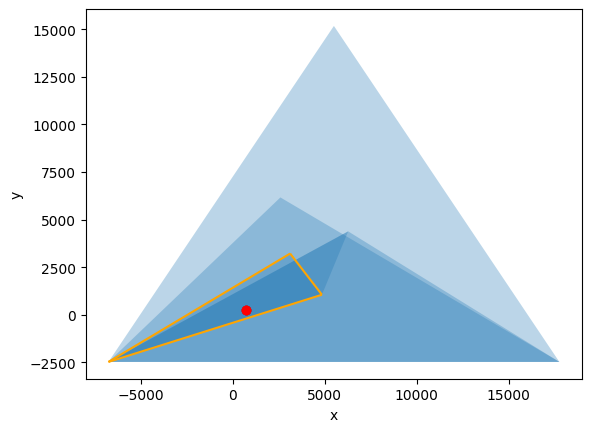

In [36]:
point_to_locate = (700,250)
print(root)
all_triangulations_copy=[all_triangulations[i].copy() for i in range(len(all_triangulations))]
found_triangle = locate_vis2(triangles_graph, root, point_to_locate, all_triangulations_copy)
print(found_triangle)